# Рубежный контроль №1 по ТМО
## Перфильев Виктор Анатольевич
## Группа ИБМ3-65Б
### Вариант 12 
#### Задача №2. Для заданного набора данных проведите обработку пропусков в данных для одного категориального и одного количественного признака. Какие способы обработки пропусков в данных для категориальных и количественных признаков Вы использовали? Какие признаки Вы будете использовать для дальнейшего построения моделей машинного обучения и почему?

## 1. Импорт библиотек

In [1]:
import sklearn as skl
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import kagglehub

## 2. Загрузка данных и первоначальный вид

In [6]:
path = kagglehub.dataset_download("lava18/google-play-store-apps")
print("Path to dataset files:", path)


Path to dataset files: /Users/admin/.cache/kagglehub/datasets/lava18/google-play-store-apps/versions/6


In [38]:
data = pd.read_csv("/Users/admin/.cache/kagglehub/datasets/lava18/google-play-store-apps/versions/6/googleplaystore.csv", )
data.head()

,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver
0,Photo Editor & Candy Camera & Grid & ScrapBook,ART_AND_DESIGN,4.1,159,19M,"10,000+",Free,0,Everyone,Art & Design,"January 7, 2018",1.0.0,4.0.3 and up
1,Coloring book moana,ART_AND_DESIGN,3.9,967,14M,"500,000+",Free,0,Everyone,Art & Design;Pretend Play,"January 15, 2018",2.0.0,4.0.3 and up
2,"U Launcher Lite – FREE Live Cool Themes, Hide ...",ART_AND_DESIGN,4.7,87510,8.7M,"5,000,000+",Free,0,Everyone,Art & Design,"August 1, 2018",1.2.4,4.0.3 and up
3,Sketch - Draw & Paint,ART_AND_DESIGN,4.5,215644,25M,"50,000,000+",Free,0,Teen,Art & Design,"June 8, 2018",Varies with device,4.2 and up
4,Pixel Draw - Number Art Coloring Book,ART_AND_DESIGN,4.3,967,2.8M,"100,000+",Free,0,Everyone,Art & Design;Creativity,"June 20, 2018",1.1,4.4 and up


In [39]:
data.shape

(10841, 13)

In [40]:
data.dtypes

App                object
Category           object
Rating            float64
Reviews            object
Size               object
Installs           object
Type               object
Price              object
Content Rating     object
Genres             object
Last Updated       object
Current Ver        object
Android Ver        object
dtype: object

#### Числовой тип данных имеет только колонка Rating, если в ней будут пропуски, то для моего задания её будет достаточно, но в противном случае можно были преобразовать, например, колонку Install (убрать знак + в конце) или колонку Reviews (убрать значок М и перевести в миллионы)

## 3. Проверка наличия пропусков 

In [41]:
data.isnull().sum()

App                  0
Category             0
Rating            1474
Reviews              0
Size                 0
Installs             0
Type                 1
Price                0
Content Rating       1
Genres               0
Last Updated         0
Current Ver          8
Android Ver          3
dtype: int64

#### Отлично, имеем пропуски в Rating, Type, Content Rating, Current Ver и Android Ver. Все эьти признаки, кроме Rating, являются типом данных object. А значит под задание всё складывается великолепно)

## 4. Обработка пропусков количественных данных
#### Для обработки пропусков данного типа было выбрано удаление строк. Это можно объяснить тем, что если бы я хотел обучать какую-нибудь модель по этим данным, то было бы неправильно, например, заполнять значение средним по приложениям той же категории или средним по общему столбцу, так как это было бы очень далеко от реальности и могло повлиять на что-нибудь важное при обучении (в зависимости от поставленной цели).

In [43]:
# Удаление строк, содержащих пустые значения
data_new_1 = data.dropna(axis=0, how='any')
(data.shape, data_new_1.shape)

((10841, 13), (9360, 13))

## 5. Обработка пропусков категориальных данных

In [44]:
cat_cols = []
for col in data.columns:
    # Количество пустых значений 
    temp_null_count = data[data[col].isnull()].shape[0]
    dt = str(data[col].dtype)
    if temp_null_count>0 and (dt=='object'):
        cat_cols.append(col)
        temp_perc = round((temp_null_count / total_count) * 100.0, 2)
        print('Колонка {}. Тип данных {}. Количество пустых значений {}, {}%.'.format(col, dt, temp_null_count, temp_perc))

Колонка Type. Тип данных object. Количество пустых значений 1, 0.01%.
Колонка Content Rating. Тип данных object. Количество пустых значений 1, 0.01%.
Колонка Current Ver. Тип данных object. Количество пустых значений 8, 0.09%.
Колонка Android Ver. Тип данных object. Количество пустых значений 3, 0.03%.


#### Так как очень мало значений пропущено, то можно было бы их и удалить, но чтобы не повторяться, будем импьютировать)

In [46]:
from sklearn.impute import SimpleImputer
cat_imputer = SimpleImputer(strategy='most_frequent')
cat_cols = data.select_dtypes(include=['object', 'category']).columns
data[cat_cols] = cat_imputer.fit_transform(data[cat_cols])
data.head()

,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver
0,Photo Editor & Candy Camera & Grid & ScrapBook,ART_AND_DESIGN,4.1,159,19M,"10,000+",Free,0,Everyone,Art & Design,"January 7, 2018",1.0.0,4.0.3 and up
1,Coloring book moana,ART_AND_DESIGN,3.9,967,14M,"500,000+",Free,0,Everyone,Art & Design;Pretend Play,"January 15, 2018",2.0.0,4.0.3 and up
2,"U Launcher Lite – FREE Live Cool Themes, Hide ...",ART_AND_DESIGN,4.7,87510,8.7M,"5,000,000+",Free,0,Everyone,Art & Design,"August 1, 2018",1.2.4,4.0.3 and up
3,Sketch - Draw & Paint,ART_AND_DESIGN,4.5,215644,25M,"50,000,000+",Free,0,Teen,Art & Design,"June 8, 2018",Varies with device,4.2 and up
4,Pixel Draw - Number Art Coloring Book,ART_AND_DESIGN,4.3,967,2.8M,"100,000+",Free,0,Everyone,Art & Design;Creativity,"June 20, 2018",1.1,4.4 and up


In [47]:
data.isnull().sum()

App                  0
Category             0
Rating            1474
Reviews              0
Size                 0
Installs             0
Type                 0
Price                0
Content Rating       0
Genres               0
Last Updated         0
Current Ver          0
Android Ver          0
dtype: int64

# Важно!
#### Можно заметить, что пропуски в категоривальных данных тут ещё остались, но там я создал новый файл, чтобы показать, что я удалял те строки. А тут я импьютировал в изначальную data. Причина крайне простая - везде, где есть категориальные пропуски, есть и пропуски из столбца Rating, а следовательно они удалились до этого и перестали быть пропусками))

## 6. Построение гистограммы
#### Гистограмму будем строить для единственной колонки, для которой её можно построить, то есть колонки Rating (и при том будем строить для data_new_1, где пропуски удалены)

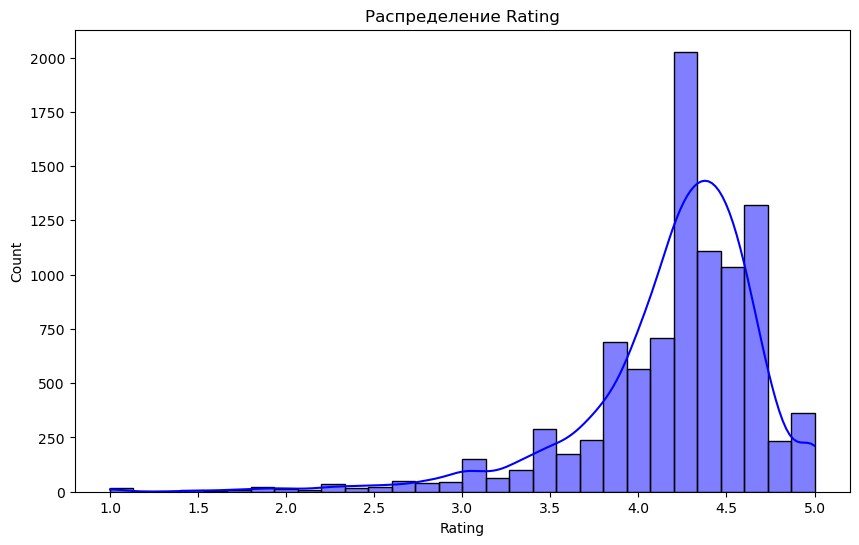

In [48]:
plt.figure(figsize=(10, 6))
sns.histplot(data=data_new_1, x='Rating', bins=30, kde=True, color='blue')
plt.title('Распределение Rating')
plt.show()

## Выводы / Ответы на вопросы

#### Я использовал два типа работы с пропусками в данных: удаление и импьютацию наиболее частыми значениями. Буду честен, я довольно неаккуратно удалил чуть больше 10% от всех данных, когда обрабатывал пропуски в количественных, так делать не очень хорошо, но и заполнение медианным значением мне тоже нравится в данном случае не очень, хотя может и тут один из довольно благоприятных случаев, где так можно (я так и не решил, но склоняюсь больше к тому, что лучше было удалить).

#### В дальнейшем я бы использовал удаление, когда процент от общего количества данных был бы в районе 1-2% и когда данные не очень важны (ну, не ситуация когда я бы заполнял уровень холестерина в крови как медиану, а модель бы училась предсказывать инфаркт). А в случае когда данные носят случайный характер и импьютация искусственно не занижает дисперсию и тем самым не может создавать смещение в сторону популярного класса. 